### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [818]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [819]:
data = pd.read_csv('data\coupons.csv')

In [820]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


__To get a general idea on the number of rows in the data frame__

In [821]:
data.shape

(12684, 26)

__To get an idea on the numerical columns of the data frame__

In [822]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [823]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

__Code to list which columns of the dataset have NAs and their respective count__

In [824]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

__A heatmap will help visualize the extent to missing data for various columns__

<Axes: >

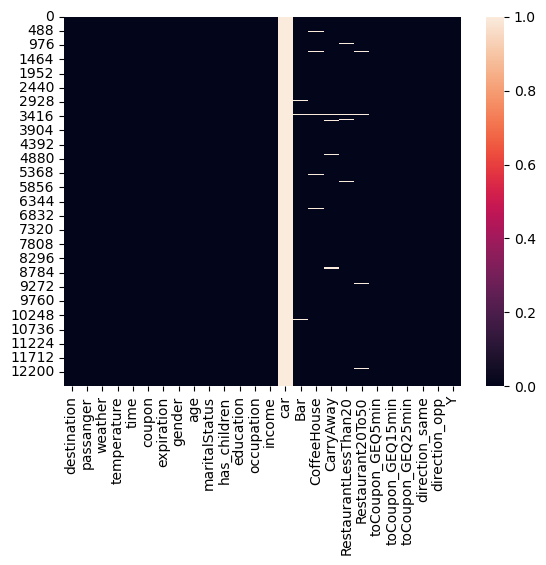

In [825]:
sns.heatmap(data.isna())

__Trying to get more familiar with the dataset by studying its unique values further__

In [826]:
print(data['destination'].unique())
print(data['passanger'].unique())
print(data['weather'].unique())
print(data['temperature'].unique())
print(data['time'].unique())
print(data['coupon'].unique())
print(data['expiration'].unique())
print(data['gender'].unique())
print(data['age'].unique())
print(data['maritalStatus'].unique())
print(data['has_children'].unique())
print(data['education'].unique())
print(data['occupation'].unique())
print(data['income'].unique())
print(data['car'].unique())
print(data['Bar'].unique())
print(data['CoffeeHouse'].unique())
print(data['CarryAway'].unique())
print(data['RestaurantLessThan20'].unique())
print(data['Restaurant20To50'].unique())
print(data['toCoupon_GEQ5min'].unique())
print(data['toCoupon_GEQ15min'].unique())
print(data['toCoupon_GEQ25min'].unique())
print(data['direction_same'].unique())
print(data['direction_opp'].unique())
print(data['Y'].unique())

['No Urgent Place' 'Home' 'Work']
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
['Sunny' 'Rainy' 'Snowy']
[55 80 30]
['2PM' '10AM' '6PM' '7AM' '10PM']
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
['1d' '2h']
['Female' 'Male']
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
[1 0]
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 'Trans

In [827]:
data['car'].value_counts()

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64

In [828]:
data['Bar'].value_counts()

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64

In [829]:
data['CoffeeHouse'].value_counts()

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64

In [830]:
data['CarryAway'].value_counts()

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64

In [831]:
data['RestaurantLessThan20'].value_counts()

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64

In [832]:
data['Restaurant20To50'].value_counts()

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

__Calculating the % of misisng data in 'car' column and then deciding to drop it because 99% of the data is missing__

In [833]:
a = data["car"].isna().mean()*100
a

np.float64(99.14853358561967)

In [834]:
data_wo_car = data.drop(columns=['car'])

Confirming the column dropped from the data set and assigning it to new data set

In [835]:
data_wo_car.shape

(12684, 25)

Calculating the % of missing data for the remaining columns with missing values and analyzing % of data missing and then plotting it on a chart to visualize it.

In [836]:
b = data["Bar"].isna().mean()*100
b

np.float64(0.8435824660990224)

In [837]:
c = data["CoffeeHouse"].isna().mean()*100
c

np.float64(1.7108167770419427)

In [838]:
d = data["CarryAway"].isna().mean()*100
d

np.float64(1.1904761904761905)

In [839]:
e = data["RestaurantLessThan20"].isna().mean()*100
e

np.float64(1.0249132765689057)

In [840]:
f = data['Restaurant20To50'].isna().mean()*100
f

np.float64(1.490066225165563)

Text(0.5, 1.0, 'Percentages of missing data')

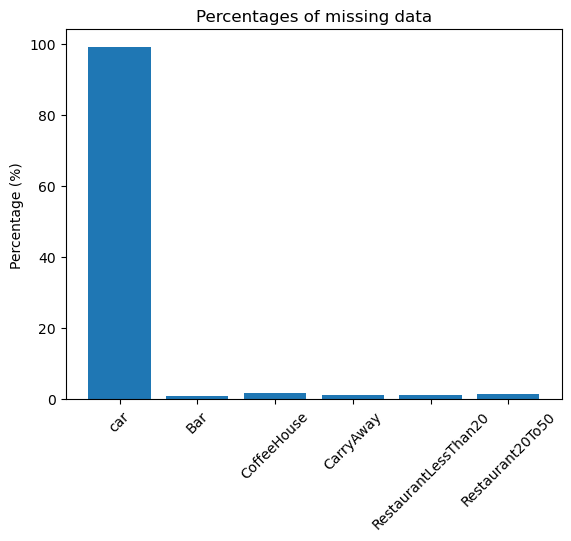

In [841]:
percentages = [a, b, c, d, e, f]
labels = ['car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

plt.bar(labels, percentages)
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.title("Percentages of missing data")

__Decided to drop rows with missing values in the columns with missing data. This is becasue the % of missing values were very low.
Another approach would also have been replacing the missing data with the most frequent values.
Because the dataset is fairly large, I went ahead with just dropna() command.__

In [842]:
data_cleaned = data_wo_car.dropna()

Analyzing remaining rows in the data set after dropping missing values

In [843]:
data_cleaned.shape

(12079, 25)

4. What proportion of the total observations chose to accept the coupon?



__The approach would be querying for Y = 1 from the 'data_cleaned' dataset  and then calculating the % compared to total. Also plotting the pie chart to show the distribution.__

In [844]:
Y_1_count = data_cleaned.query('Y == 1')['Y'].count()
Y_1_count

np.int64(6877)

In [845]:
Y_0_count = data_cleaned.query('Y == 0')['Y'].count()
Y_0_count

np.int64(5202)

In [846]:
perc_accepted = Y_1_count/len(data_cleaned)*100
print(f'Coupon acceptance percentage is {perc_accepted:.2f}%')

Coupon acceptance percentage is 56.93%


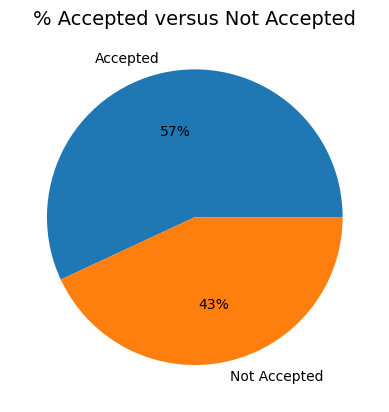

In [847]:
data_pie = [Y_1_count, Y_0_count]
labels_pie = ['Accepted', 'Not Accepted']
plt.pie(data_pie, labels=labels_pie, autopct='%.0f%%')
plt.title("% Accepted versus Not Accepted", fontsize=14)
plt.show()

5. Use a bar plot to visualize the `coupon` column.

__Finding out categories under 'coupon' column along with their count and then plotting it as a bar chart for showing the visual.__

In [848]:
coupon_info = data_cleaned['coupon'].value_counts().reset_index()
coupon_info

,coupon,count
0,Coffee House,3816
1,Restaurant(<20),2653
2,Carry out & Take away,2280
3,Bar,1913
4,Restaurant(20-50),1417


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Coffee House'),
  Text(1, 0, 'Restaurant(<20)'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

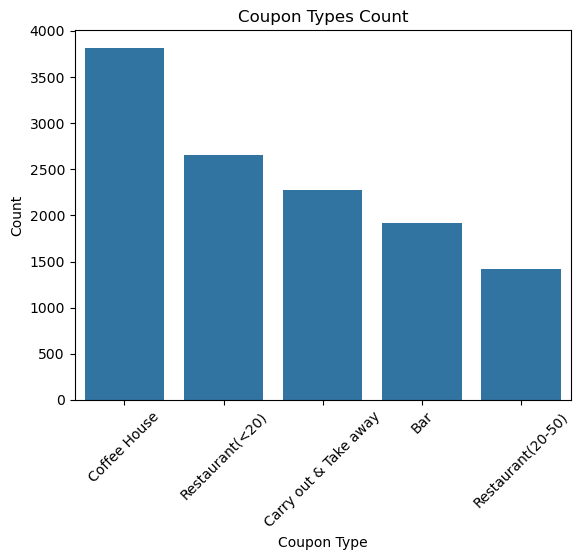

In [849]:
sns.barplot(x = 'coupon', y = 'count', data = coupon_info)
plt.title('Coupon Types Count')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

6. Use a histogram to visualize the temperature column.

__The temperature histogram plot shows the count against various temperature values.
Also plotting a separate histogram to show the internal distribution of coupons in the overall plot.__

Text(0, 0.5, 'Count')

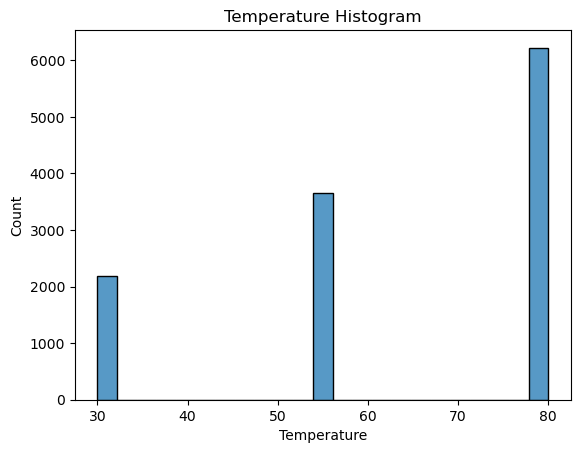

In [850]:
sns.histplot(data=data_cleaned, x='temperature')
plt.title('Temperature Histogram')
plt.xlabel('Temperature')
plt.ylabel('Count')

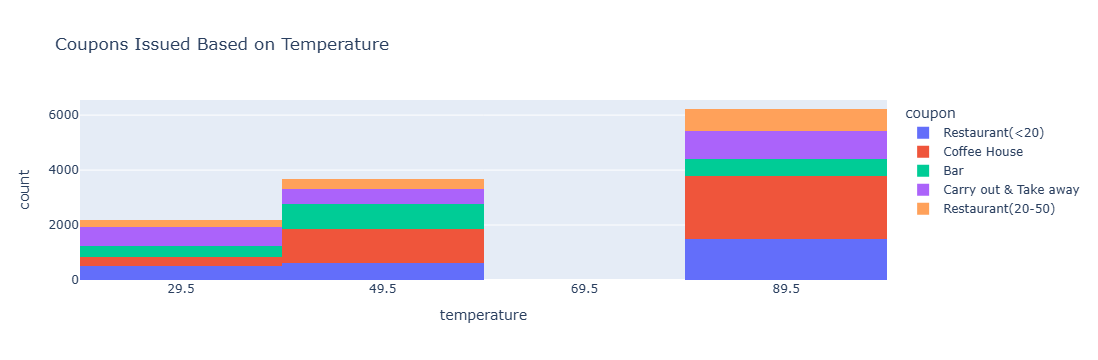

In [851]:
import plotly.express as px
px.histogram(data_cleaned, x='temperature', color='coupon', title="Coupons Issued Based on Temperature")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [852]:
data_bar_coupons = data_cleaned.query('coupon == "Bar"')
data_bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


__Getting idea on the # of rows within the bar coupons dataset. The calculating the acceptance rate as % of total.
Also shows distribution on pie chart.__

In [853]:
data_bar_coupons.shape

(1913, 25)

2. What proportion of bar coupons were accepted?


In [854]:
yes_bar = len(data_bar_coupons.query('Y == 1'))
yes_bar

788

In [855]:
no_bar = len(data_bar_coupons.query('Y == 0'))
no_bar

1125

In [856]:
perc_bar_accepted = yes_bar/len(data_bar_coupons)*100
print(f'Coupon acceptance percentage is {perc_bar_coupon_accepted:.2f}%')

Coupon acceptance percentage is 41.19%


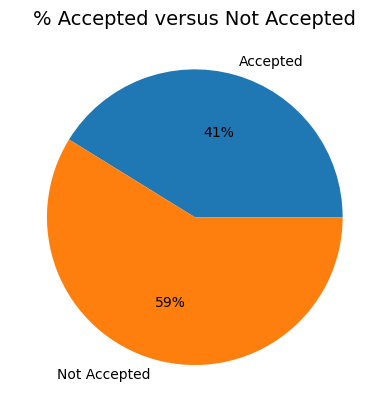

In [857]:
data_pie_bar = [yes_bar, no_bar]
labels_pie_bar = ['Accepted', 'Not Accepted']
plt.pie(data_pie_bar, labels=labels_pie_bar, autopct='%.0f%%')
plt.title("% Accepted versus Not Accepted", fontsize=14)
plt.show()

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


__The below plot provides a general idea of how the data looks with respect to acceptance or not for the bar coupons dataset.__

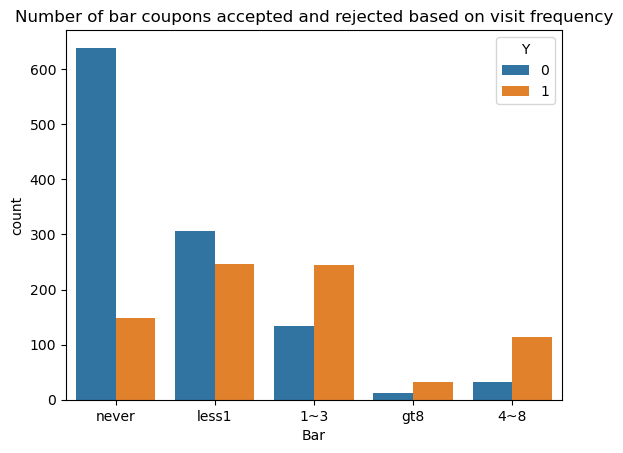

In [858]:
sns.countplot(data=data_bar_coupons,x="Bar",hue="Y")

plt.title("Number of bar coupons accepted and rejected based on visit frequency",fontsize=12)
plt.xlabel("Bar", fontsize=10)
plt.ylabel("count", fontsize=10)
plt.legend(title="Y")

__The approach is to create a relevant dataset as per the question and have used query() command to achieve the required data in a setp by step approach.<br>
Total dataset: 1913<br>
-those who went to a bar 3 or fewer times a month: 1720<br>
     -Y1:641<br>
     -Y0:1079<br>
-those who went to a bar more than 3 times a month: 193<br>
     -Y1:147<br>
     -Y0:46__

In [859]:
#Bar unique values: ['never' 'less1' '1~3' 'gt8' nan '4~8']
bar_freq_low = ['never','less1','1~3']
data_bar_freq_low = data_bar_coupons.query('Bar in @bar_freq_low')
data_bar_freq_low.shape

(1720, 25)

In [860]:
data_bar_freq_low_1 = data_bar_freq_low.query('Y == 1')
data_bar_freq_low_1.shape

(641, 25)

In [861]:
acceptance_rate_bar_low = len(data_bar_freq_low_1)/len(data_bar_freq_low)*100
print(f'Acceptance rate of those who went to a bar 3 or fewer times a month is {acceptance_rate_bar_low:.2f}%')

Acceptance rate of those who went to a bar 3 or fewer times a month is 37.27%


In [862]:
#Bar unique values: ['never' 'less1' '1~3' 'gt8' nan '4~8']
bar_freq_high = ['4~8','gt8']
data_bar_freq_high = data_bar_coupons.query('Bar in @bar_freq_high')
data_bar_freq_high.shape

(193, 25)

In [863]:
data_bar_freq_high_1 = data_bar_freq_high.query('Y == 1')
data_bar_freq_high_1.shape

(147, 25)

In [864]:
acceptance_rate_bar_high = len(data_bar_freq_high_1)/len(data_bar_freq_high)*100
print(f'Acceptance rate of those who went to a bar 4 or more times a month is {acceptance_rate_bar_high:.2f}%')

Acceptance rate of those who went to a bar 4 or more times a month is 76.17%


In [865]:
print(f'Difference in acceptance rate of those who went to a bar 3 or fewer times a month than those who went more is {(acceptance_rate_bar_high-acceptance_rate_bar_low):.2f}%')

Difference in acceptance rate of those who went to a bar 3 or fewer times a month than those who went more is 38.90%


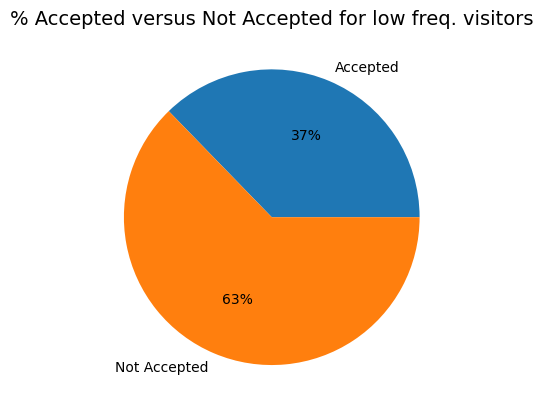

In [866]:
yes_bar_low = len(data_bar_freq_low_1)
no_bar_low = len(data_bar_freq_low)-yes_bar_low
data_pie_bar_low = [yes_bar_low, no_bar_low]
labels_pie_bar_low = ['Accepted', 'Not Accepted']
plt.pie(data_pie_bar_low, labels=labels_pie_bar_low, autopct='%.0f%%')
plt.title("% Accepted versus Not Accepted for low freq. visitors", fontsize=14)
plt.show()

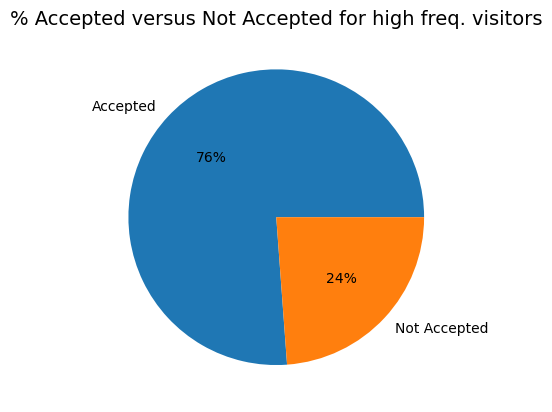

In [867]:
yes_bar_high = len(data_bar_freq_high_1)
no_bar_high = len(data_bar_freq_high)-yes_bar_high
data_pie_bar_high = [yes_bar_high, no_bar_high]
labels_pie_bar_high = ['Accepted', 'Not Accepted']
plt.pie(data_pie_bar_high, labels=labels_pie_bar_high, autopct='%.0f%%')
plt.title("% Accepted versus Not Accepted for high freq. visitors", fontsize=14)
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


__The approach is to create a relevant dataset as per the question by using query() command to achieve the required data in a setp by step approach.<br>
Total dataset rows: 1913<br>
-those who went to a bar more than once a month: 572<br>
     -age over 25: 403<br>
          -Y1: 278<br>
          -Y0: 125<br>
     -age under 25: 169<br>
          -Y1: 114<br>
          -Y0: 55<br>
-those who went to a bar less than once a month: 1341<br>
     -age over 25: 1032<br>
          -Y1: 276<br>
          -Y0: 756<br>
     -age under 25: 309<br>
          -Y1: 120<br>
          -Y0: 189__

In [868]:
freq_bar_drivers = ['1~3','4~8','gt8']
data_freq_bar_drivers = data_bar_coupons.query('Bar in @freq_bar_drivers')
age_over_25 = ['46','26','31','41','50plus','36']
frequent_bar_drivers_over_25 = data_freq_bar_drivers.query('age in @age_over_25')
frequent_bar_drivers_over_25.shape

(403, 25)

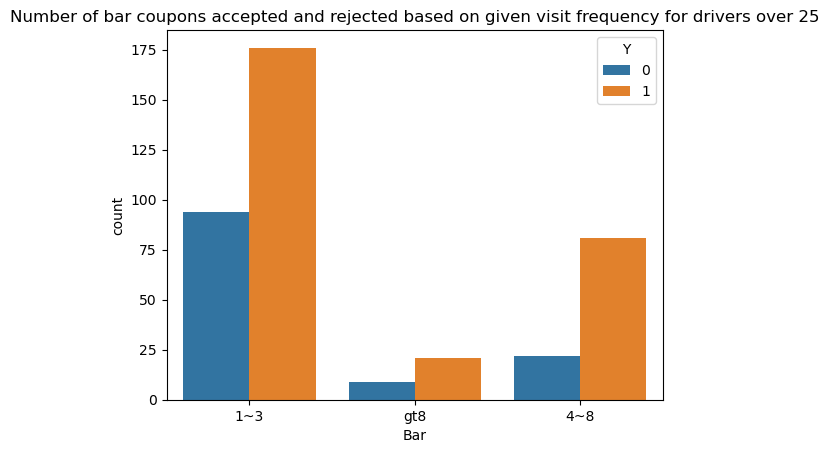

In [869]:
sns.countplot(data=frequent_bar_drivers_over_25,x="Bar",hue="Y")

plt.title("Number of bar coupons accepted and rejected based on given visit frequency for drivers over 25",fontsize=12)
plt.xlabel("Bar", fontsize=10)
plt.ylabel("count", fontsize=10)
plt.legend(title="Y")

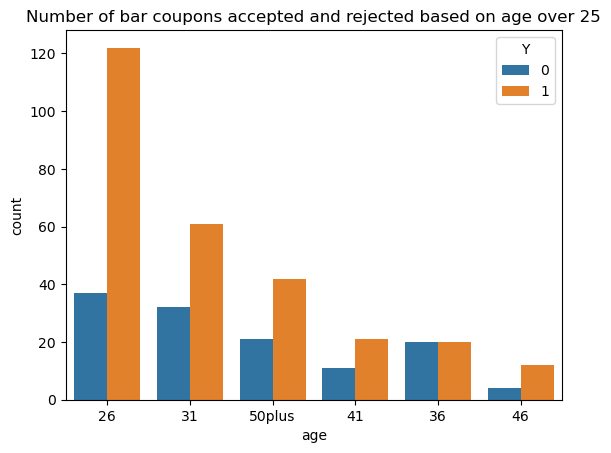

In [870]:
sns.countplot(data=frequent_bar_drivers_over_25,x="age",hue="Y")

plt.title("Number of bar coupons accepted and rejected based on age over 25",fontsize=12)
plt.xlabel("age", fontsize=10)
plt.ylabel("count", fontsize=10)
plt.legend(title="Y")

In [871]:
frequent_bar_drivers_over_25_Y_1=frequent_bar_drivers_over_25.query('Y==1')
frequent_bar_drivers_over_25_Y_1.shape

(278, 25)

In [872]:
acceptance_rate_frequent_bar_drivers_over_25=len(frequent_bar_drivers_over_25_Y_1)/len(frequent_bar_drivers_over_25)*100
print(f'Acceptance rate of those who went to a bar more than once a month and are over the age of 25 is {acceptance_rate_frequent_bar_drivers_over_25:.2f}%')

Acceptance rate of those who went to a bar more than once a month and are over the age of 25 is 68.98%


In [873]:
#Bar unique values: ['never' 'less1' '1~3' 'gt8' '4~8']
#age unique values: ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
less_freq_bar_drivers = ['never','less1']
data_less_freq_bar_drivers = data_bar_coupons.query('Bar in @less_freq_bar_drivers')
age_under_25 = ['below21','21']
less_frequent_bar_drivers_under_25 = data_less_freq_bar_drivers.query('age in @age_under_25')
less_frequent_bar_drivers_under_25.shape

(309, 25)

In [874]:
less_frequent_bar_drivers_under_25_Y_1=less_frequent_bar_drivers_under_25.query('Y==1')
less_frequent_bar_drivers_under_25_Y_1.shape

(120, 25)

In [875]:
frequent_bar_drivers_under_25 = data_freq_bar_drivers.query('age in @age_under_25')
frequent_bar_drivers_under_25.shape

(169, 25)

In [876]:
frequent_bar_drivers_under_25_Y_1=frequent_bar_drivers_under_25.query('Y==1')
frequent_bar_drivers_under_25_Y_1.shape

(114, 25)

In [877]:
less_frequent_bar_drivers_over_25 = data_less_freq_bar_drivers.query('age in @age_over_25')
less_frequent_bar_drivers_over_25.shape

(1032, 25)

In [878]:
less_frequent_bar_drivers_over_25_Y_1=less_frequent_bar_drivers_over_25.query('Y==1')
less_frequent_bar_drivers_over_25_Y_1.shape

(276, 25)

In [879]:
acceptance_rate_bar_all_others=((len(frequent_bar_drivers_under_25_Y_1)+
                                 len(less_frequent_bar_drivers_over_25_Y_1)+
                                 len(less_frequent_bar_drivers_under_25_Y_1))/
                                (len(frequent_bar_drivers_under_25)+
                                 len(less_frequent_bar_drivers_over_25)+
                                 len(less_frequent_bar_drivers_under_25)))*100
print(f'Acceptance rate of all others is {acceptance_rate_bar_all_others:.2f}%')

Acceptance rate of all others is 33.77%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


__The approach is to create a relevant dataset as per the question by using query() command to achieve the required data in a setp by step approach.<br>
Total dataset rows: 1913<br>
-those who went to a bar more than once a month: 572<br>
     -yes kid: 169<br>
          -farming, fishing, or forestry occupation:0<br>
          -other occupation:169<br>
     -no kid: 403<br>
         -farming, fishing, or forestry occupation:0<br>
         -other occupation:403<br>
               -Y1: 283<br>
               -Y0: 120<br>
-those who went to a bar less than once a month: 1341<br>
     -yes kid: 649<br>
          -farming, fishing, or forestry occupation:9<br>
          -other occupation:640<br>
     -no kid: 692<br>
         -farming, fishing, or forestry occupation:0<br>
         -other occupation:692__

In [880]:
data_bar_coupons.shape

(1913, 25)

In [881]:
data_freq_bar_drivers.shape

(572, 25)

In [882]:
data_freq_bar_drivers_no_kids = data_freq_bar_drivers.query('has_children == 0')
data_freq_bar_drivers_no_kids.shape

(403, 25)

Confirming that for the occupation"Farming Fishing & Forestry", those drivers have kids and are less frequant drivers

In [883]:
data_bar_coupons.query('occupation == "Farming Fishing & Forestry"')['has_children']

8431    1
8432    1
8438    1
8445    1
9558    1
9565    1
9568    1
9571    1
9574    1
Name: has_children, dtype: int64

In [884]:
data_bar_coupons.query('occupation == "Farming Fishing & Forestry"')['Bar']

8431    never
8432    never
8438    never
8445    never
9558    less1
9565    less1
9568    less1
9571    less1
9574    less1
Name: Bar, dtype: object

In [885]:
#Bar unique values: ['never' 'less1' '1~3' 'gt8' '4~8']
#has_children unique values: [1 0]
#occupation unique values: ['Unemployed' 'Architecture & Engineering' 'Student' 'Education&Training&Library' 'Healthcare Support'
#'Healthcare Practitioners & Technical' 'Sales & Related' 'Management' 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
#'Life Physical Social Science' 'Personal Care & Service' 'Community & Social Services' 'Office & Administrative Support'
#'Construction & Extraction' 'Legal' 'Retired' 'Installation Maintenance & Repair' 'Transportation & Material Moving'
#'Business & Financial' 'Protective Service''Food Preparation & Serving Related' 'Production Occupations
# 'Building & Grounds Cleaning & Maintenance' 'Farming Fishing & Forestry']

occupation_yes = ['Unemployed','Architecture & Engineering','Student','Education&Training&Library','Healthcare Support',
                  'Healthcare Practitioners & Technical','Sales & Related','Management','Arts Design Entertainment Sports & Media',
                  'Computer & Mathematical','Life Physical Social Science','Personal Care & Service','Community & Social Services',
                  'Office & Administrative Support','Construction & Extraction','Legal','Retired','Installation Maintenance & Repair',
                  'Transportation & Material Moving','Business & Financial','Protective Service','Food Preparation & Serving Related',
                  'Production Occupations','Building & Grounds Cleaning & Maintenance']
data_freq_bar_drivers_no_kids_no_f_occu = data_freq_bar_drivers_no_kids.query('occupation in @occupation_yes')
data_freq_bar_drivers_no_kids_no_f_occu.shape

(403, 25)

In [886]:
data_freq_bar_drivers_no_kids_no_f_occu_Y_1 = data_freq_bar_drivers_no_kids_no_f_occu.query('Y==1')
data_freq_bar_drivers_no_kids_no_f_occu_Y_1.shape

(283, 25)

In [887]:
data_freq_bar_drivers_no_kids['occupation'].unique()

array(['Student', 'Healthcare Support', 'Management', 'Unemployed',
       'Sales & Related', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal',
       'Life Physical Social Science',
       'Healthcare Practitioners & Technical',
       'Architecture & Engineering', 'Protective Service',
       'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Food Preparation & Serving Related',
       'Education&Training&Library', 'Community & Social Services',
       'Production Occupations', 'Business & Financial',
       'Transportation & Material Moving'], dtype=object)

In [888]:
q5_acceptance_rate = len(data_freq_bar_drivers_no_kids_no_f_occu_Y_1)/len(data_freq_bar_drivers_no_kids_no_f_occu)*100
print(f'Acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry {q5_acceptance_rate:.2f}%')

Acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry 70.22%


__Creating a dataset with anything other than the criteria defined in the question and then finding acceptance rate.__

In [889]:
data_others = data_bar_coupons.drop(data_freq_bar_drivers_no_kids_no_f_occu.index)
data_others.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1510 entries, 24 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1510 non-null   object
 1   passanger             1510 non-null   object
 2   weather               1510 non-null   object
 3   temperature           1510 non-null   int64 
 4   time                  1510 non-null   object
 5   coupon                1510 non-null   object
 6   expiration            1510 non-null   object
 7   gender                1510 non-null   object
 8   age                   1510 non-null   object
 9   maritalStatus         1510 non-null   object
 10  has_children          1510 non-null   int64 
 11  education             1510 non-null   object
 12  occupation            1510 non-null   object
 13  income                1510 non-null   object
 14  Bar                   1510 non-null   object
 15  CoffeeHouse           1510 non-null   obj

In [890]:
data_others_Y_1=data_others.query('Y == 1')
data_others_Y_1.shape

(505, 25)

In [891]:
others_acceptance_rate = len(data_others_Y_1)/len(data_others)*100
print(f'Acceptance rate others {others_acceptance_rate:.2f}%')

Acceptance rate others 33.44%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



__Segregating each group to see the acceptance rate compared to the bar coupons dataset.__

In [892]:
#Bar unique values: ['never' 'less1' '1~3' 'gt8' '4~8']
#martial Status unique values: ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
#passanger unique values: ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']

#group_a is those whogo to bars more than once a month, had passengers that were not a kid, and were not widowed
group_a = data_bar_coupons[
    (data_bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (data_bar_coupons['passanger'] != 'Kid(s)') &
    (data_bar_coupons['maritalStatus'] != 'Widowed')
]
group_a.shape

(530, 25)

In [893]:
#age unique values: ['21' '46' '26' '31' '41' '50plus' '36' 'below21']

#group_b is those who go to bars more than once a month and are under the age of 30
group_b = data_bar_coupons[
    (data_bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (data_bar_coupons['age'].isin(['below21', '21', '26']))
]
group_b.shape

(328, 25)

In [894]:
#Restaurantlessthan20 unique values: ['4~8' '1~3' 'less1' 'gt8' nan 'never']
#income unique values: ['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
#'$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999''Less than $12500']

#group_c is those who go to cheap restaurants more than 4 times a month and income is less than 50K
group_c = data_bar_coupons[
    (data_bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (data_bar_coupons['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ]))
]
group_c.shape

(333, 25)

Calculating acceptance rates groupwise and then plotting a bar chart to see comparison.

In [895]:
group_a_rate = group_a['Y'].mean() * 100
group_b_rate = group_b['Y'].mean() * 100
group_c_rate = group_c['Y'].mean() * 100
print(f'Acceptance rate in group a is {group_a_rate:.2f}%')
print(f'Acceptance rate in group b is {group_b_rate:.2f}%')
print(f'Acceptance rate in group c is {group_c_rate:.2f}%')

Acceptance rate in group a is 70.94%
Acceptance rate in group b is 71.95%
Acceptance rate in group c is 45.65%


([0, 1, 2],
 [Text(0, 0, 'group_a'), Text(1, 0, 'group_b'), Text(2, 0, 'group_c')])

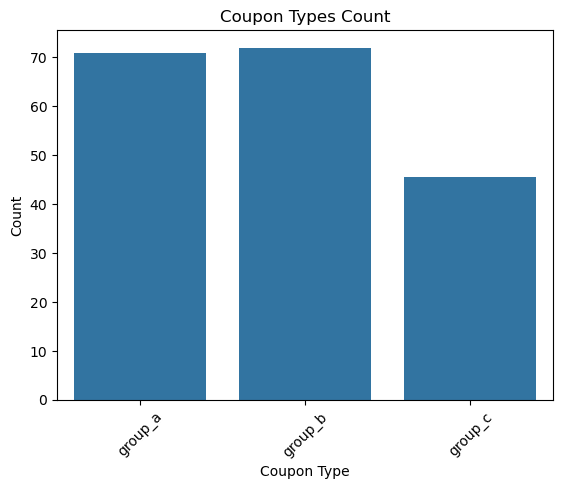

In [896]:
groups = ['group_a', 'group_b', 'group_c']
group_rates = [group_a_rate, group_b_rate, group_c_rate]


sns.barplot(x = groups, y = group_rates)
plt.title('Coupon Types Count')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

__Based on the data observations, the lower income drivers who frequently visit cheap restaurants are less likely to accept a coupon versus those who are frequent bar visitors under age 30 or frequent bar visitors who are not with kids and have companions. Higher acceptances rates are linked to social commuters and young drivers as they are more likely to accept coupons when they go to a bar frequently.<br>
<br>__
__Recommendation for bar coupon group:<br>__
1. Target young drivers for promotions<br>
2. Target frequent goers for promotions<br>
3. Marketing team should run campaigns that are for social drivers rather than individual commuters

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

__Choosing the 'Carry out & Take away' group for independent investigation to determine the characteristics of passengers who accept the coupons.
Creating a new DataFrame that contains just the 'Carry out & Take away' coupons.__

In [897]:
data_cota_coupons = data_cleaned.query('coupon == "Carry out & Take away"')
data_cota_coupons.shape

(2280, 25)

Calculating the acceptance rates

In [898]:
yes_cota = len(data_cota_coupons.query('Y == 1'))
yes_cota

1682

In [899]:
no_cota = len(data_cota_coupons.query('Y == 0'))
no_cota

598

In [900]:
rate_accepted = yes_cota/len(data_cota_coupons)*100
print(f'Coupon acceptance percentage is {rate_accepted:.2f}%')

Coupon acceptance percentage is 73.77%


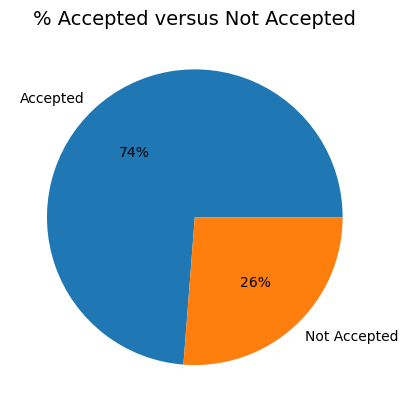

In [901]:
data_pie_cota = [yes_cota, no_cota]
labels_pie_cota = ['Accepted', 'Not Accepted']
plt.pie(data_pie_cota, labels=labels_pie_bar, autopct='%.0f%%')
plt.title("% Accepted versus Not Accepted", fontsize=14)
plt.show()

__About 3/4th of the 'Carry out & Take away' coupons are accepted which is high compared to 'Bar' coupon acceptance rate of 41%. The below plot provides a general idea of how the data looks with respect to acceptance or not for the 'Carry out & Take away' coupons dataset.__

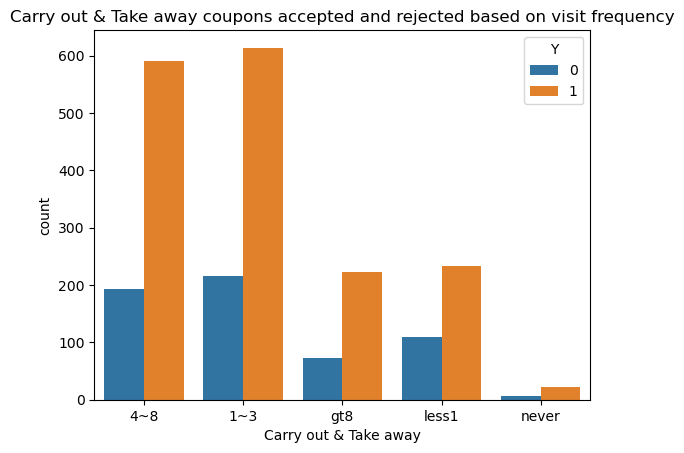

In [902]:
sns.countplot(data=data_cota_coupons,x='CarryAway',hue='Y')

plt.title("Carry out & Take away coupons accepted and rejected based on visit frequency",fontsize=12)
plt.xlabel("Carry out & Take away", fontsize=10)
plt.ylabel("count", fontsize=10)
plt.legend(title="Y")

__% acceptance by groups__

In [903]:
group_never = data_cota_coupons[(data_cota_coupons['CarryAway'].isin(['never']))]
print(group_never.shape)
group_less1 = data_cota_coupons[(data_cota_coupons['CarryAway'].isin(['less1']))]
print(group_less1.shape)
group_1_to_3 = data_cota_coupons[(data_cota_coupons['CarryAway'].isin(['1~3']))]
print(group_1_to_3.shape)
group_4_to_8 = data_cota_coupons[(data_cota_coupons['CarryAway'].isin(['4~8']))]
print(group_4_to_8.shape)
group_gt8 = data_cota_coupons[(data_cota_coupons['CarryAway'].isin(['gt8']))]
print(group_gt8.shape)

(28, 25)
(343, 25)
(830, 25)
(783, 25)
(296, 25)


__Calculating acceptance rates groupwise and then plotting a bar chart to see comparison.__

In [904]:
group_never_rate = group_never['Y'].mean() * 100
group_less1_rate = group_less1['Y'].mean() * 100
group_1_to_3_rate = group_1_to_3['Y'].mean() * 100
group_4_to_8_rate = group_4_to_8['Y'].mean() * 100
group_gt8_rate = group_gt8['Y'].mean() * 100
print(f'Acceptance rate in group never is {group_never_rate:.2f}%')
print(f'Acceptance rate in group less1 is {group_less1_rate:.2f}%')
print(f'Acceptance rate in group 1~3 is {group_1_to_3_rate:.2f}%')
print(f'Acceptance rate in group 4~8 is {group_4_to_8_rate:.2f}%')
print(f'Acceptance rate in group gt8 is {group_gt8_rate:.2f}%')

Acceptance rate in group never is 78.57%
Acceptance rate in group less1 is 67.93%
Acceptance rate in group 1~3 is 73.98%
Acceptance rate in group 4~8 is 75.35%
Acceptance rate in group gt8 is 75.34%


__The acceptance rate is highest in the group 'never' versus lowest in the group 'less1' which shows that the drivers are promptly interested to try out new Caryy Out & Take Away places for the first time. However, becoming a repeat customer is slightly less unlikely.  The acceptance rates for those with visits more than a month is higher again.__

([0, 1, 2, 3, 4],
 [Text(0, 0, 'group_never'),
  Text(1, 0, 'group_less1'),
  Text(2, 0, 'group_1_to_3'),
  Text(3, 0, 'group_4_to_8'),
  Text(4, 0, 'group_gt8')])

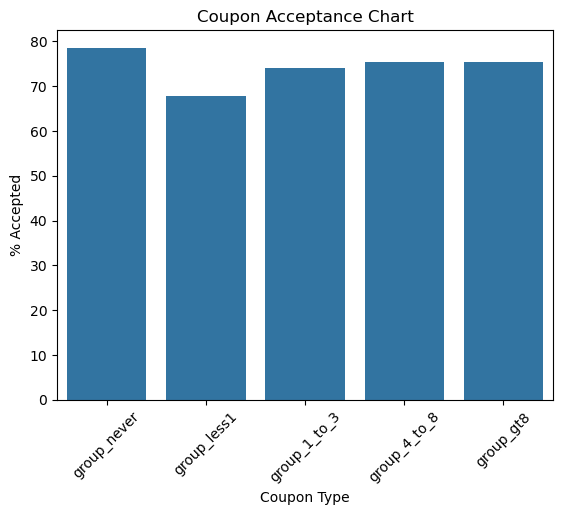

In [905]:
groups_cota = ['group_never', 'group_less1', 'group_1_to_3', 'group_4_to_8', 'group_gt8']
group_rates_cota = [group_never_rate, group_less1_rate, group_1_to_3_rate, group_4_to_8_rate, group_gt8_rate] 

sns.barplot(x=groups_cota, y=group_rates_cota) 
plt.title('Coupon Acceptance Chart') 
plt.xlabel('Coupon Type') 
plt.ylabel('% Accepted') 
plt.xticks(rotation=45)

__Using pd.get_dummies() to transform predictive columns into numeric flags (found from google search).<br>
Then calculate the correlation of acceptance rate to these selected columns.<br>
Higher the number, better the correlation.__

In [906]:
features = ['Y', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'passanger', 'time', 'weather', 'destination']
data_analysis = data_cota_coupons[features]
data_encoded = pd.get_dummies(data_analysis, columns=['passanger', 'time', 'weather', 'destination'], drop_first=False)
corr_matrix = data_encoded.corr()
target_corr = corr_matrix['Y'].sort_values(ascending=False)
print("Correlation with Coupon Acceptance (Y):")
print(target_corr)

Correlation with Coupon Acceptance (Y):
Y                              1.000000
weather_Sunny                  0.101072
time_2PM                       0.092664
time_6PM                       0.088858
destination_Home               0.075325
destination_No Urgent Place    0.045000
passanger_Friend(s)            0.033268
time_10PM                      0.033231
toCoupon_GEQ25min              0.010657
passanger_Partner             -0.009476
passanger_Alone               -0.015810
weather_Snowy                 -0.019138
passanger_Kid(s)              -0.023750
toCoupon_GEQ15min             -0.026840
time_10AM                     -0.044865
weather_Rainy                 -0.112088
time_7AM                      -0.119293
destination_Work              -0.119293
Name: Y, dtype: float64


__Findings:<br>
1.Carry-out coupons are of high convenience relief for tired drivers who want to pick up dinner on their way back from work without sitting down at a restaurant. So offering coupons in the eveving time when drivers are commuting back home will be more efficient.<br>
2. Value for 'toCoupon_GEQ25min' shows positive while 'toCoupon_GEQ15min' displays a negative correlation with acceptance.<br>
3. Rainy or Snowy weather, morning hours when drivers are going to work is not a good choice to promote coupons.__

Acceptance Rate by Temperature:

In [907]:
carryaway = data_cota_coupons[data_cota_coupons['coupon'] == 'Carry out & Take away'].copy()
acceptance_by_temp = carryaway.groupby('temperature')['Y'].mean().reset_index()
print(acceptance_by_temp)

   temperature         Y
0           30  0.760504
1           55  0.720803
2           80  0.730845


In [908]:
from sklearn.linear_model import LinearRegression

X = acceptance_by_temp[['temperature']]
Y = acceptance_by_temp['Y']

model = LinearRegression()
model.fit(X, Y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", model.score(X, Y))

Slope: -0.0005931881593501842
Intercept: 0.7700093204648817
R²: 0.5161007485603637


Linear Model: y = -0.00059x + 0.77

51.61% of the variance in Y (acceptance rate) can be explained by temperature.

Because the slope is negative, there is an inverse relationship between acceptance rate and temperature.

__Further, want to explore the relationship between the expiration and acceptance rates. 1 day coupons have better acceptance rate than 2 hour coupons.__

In [909]:
data_expiration = data_cota_coupons[data_cota_coupons['coupon'] == 'Carry out & Take away'].copy()
acceptance_by_expiry = data_expiration.groupby('expiration')['Y'].mean().reset_index()
print(acceptance_by_expiry)

  expiration         Y
0         1d  0.785612
1         2h  0.662921


Scatterplot to show the distribution of acceptance rate by age. First assing the mapping for non numberic datapoint and then group them to calculate acceptance rate.

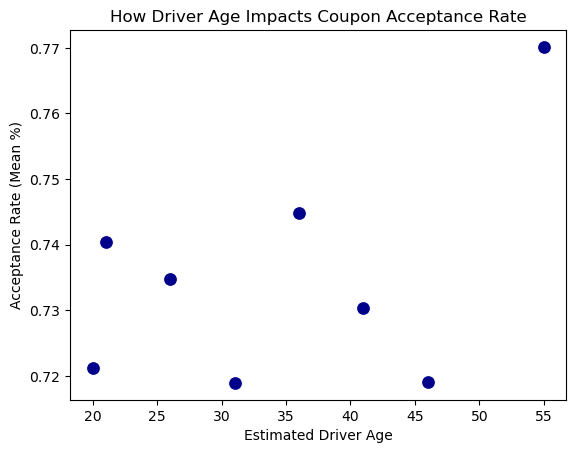

In [910]:
data_scatter = data_cota_coupons[data_cota_coupons['coupon'] == 'Carry out & Take away'].copy()
age_mapping = {'below21': 20, '21': 21, '26': 26, '31': 31, '36': 36, '41': 41, '46': 46, '50plus': 55}
data_scatter['age_numeric'] = data_scatter['age'].map(age_mapping)
grouped_data = data_scatter.groupby('age_numeric')['Y'].mean().reset_index()

sns.scatterplot(data=grouped_data, x='age_numeric', y='Y', s=100, color='darkblue')
plt.title('How Driver Age Impacts Coupon Acceptance Rate')
plt.xlabel('Estimated Driver Age')
plt.ylabel('Acceptance Rate (Mean %)')
plt.show()